# Examen 2: Inferencia Estadística

## Pregunta 1: Parametrización de Bandas de Riesgo Clínico

## Pregunta 2: Máxima Verosimilitud y el Supuesto de Equidispersión

## Pregunta 3: El Teorema del Límite Central y Riesgo de Liquidez

In [2]:
#Cargar librerías y datos:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import binom


In [3]:
df = pd.read_csv("data/raw/insurance.csv")
print(f"Dimensiones del Dataframe: {df.shape}")
df.head()


Dimensiones del Dataframe: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


3.1 **Evidencia Poblacional:** Trace un histograma de la variable charges para demostrar visualmente por qué el analista junior concluyó que la población es asimétrica.

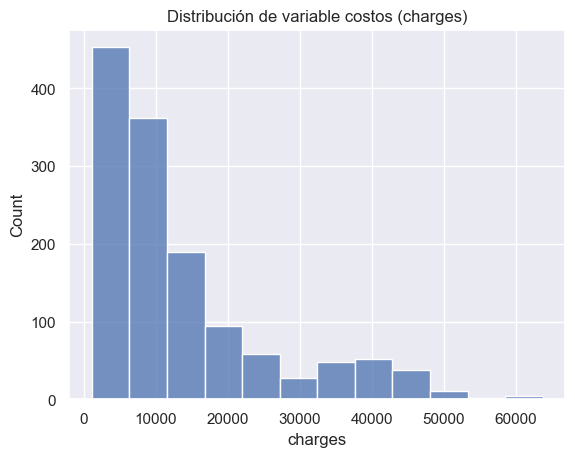

In [4]:
sns.set()
charges = df["charges"]
sns.histplot(charges, bins = "sturges")
plt.title("Distribución de variable costos (charges)")
plt.show()

Es de notar que la gran mayoría de los costos se agrupan a la izquierda (costos bajos) dejando una gran "cola" hacia la derecha (costos altísimos), lo que se conoce como **asimetria positiva**. Lo cual confirma que la población de costos no tiene un comportamiento normal

3.2 **Simulación de Monte Carlo:** Construya un experimento computacional extrayendo 5.000 muestras aleatorias (con reemplazo), cada una de tamaño n = 40, de la base de datos original. Calcule la media de cada muestra y grafique la distribución resultante de estas medias muestrales.

Para demostrar el comportamiento de las medias muestrales, realizaremos un remuestreo empírico (con reemplazo) de la población original. 
Matemáticamente, si nuestra población es $X$, extraeremos $M = 5000$ muestras, cada una representada como un vector $X_i = (x_{i1}, x_{i2}, ..., x_{in})$ con $n=40$. 
Luego, calcularemos la media muestral para cada vector:
$$\bar{X}_i = \frac{1}{n} \sum_{j=1}^{n} x_{ij}$$


--- SIMULACIÓN DE MONTE CARLO ---
Promedio de las 5000 medias muestrales: $13,261.03


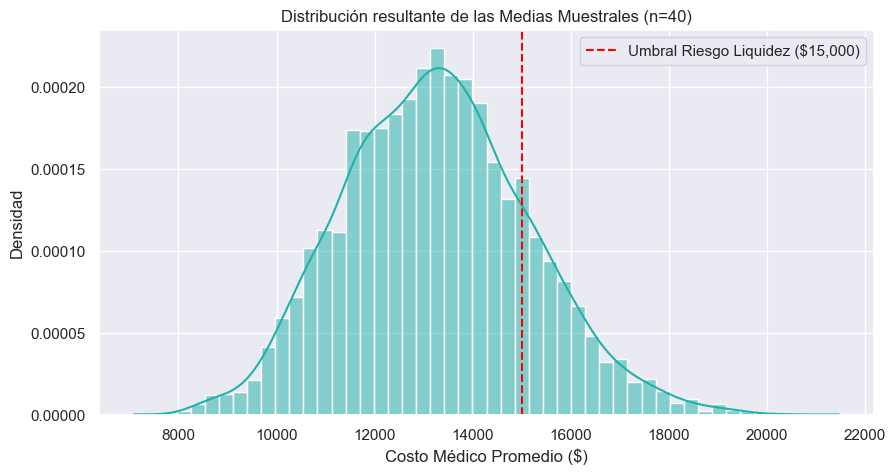

In [25]:
print("\n--- SIMULACIÓN DE MONTE CARLO ---") 

# Fijamos la semilla para reproducibilidad
np.random.seed(42)

# Parámetros de la simulación
n_muestra = 40       # Tamaño de cada lote (siniestros)
n_iteraciones = 5000 # Cantidad de muestras a extraer

# Extraemos los valores de la población original
poblacion_cargos = df['charges'].values
# VECTORIZACIÓN AVANZADA CON NUMPY:
# En lugar de usar un bucle for (que es lento), generamos una matriz de 5000 x 40 
# donde cada fila es una muestra aleatoria con reemplazo de la población.
matriz_muestras = np.random.choice(poblacion_cargos, size=(n_iteraciones, n_muestra), replace=True)

# Calculamos la media a lo largo del eje 1 (las filas), obteniendo 5000 medias muestrales
medias_muestrales = np.mean(matriz_muestras, axis=1)

print(f"Promedio de las 5000 medias muestrales: ${np.mean(medias_muestrales):,.2f}")

# --- VISUALIZACIÓN ---
plt.figure(figsize=(10, 5))

# Graficamos la distribución de las medias muestrales
sns.histplot(medias_muestrales, kde=True, bins=50, color='lightseagreen', stat='density')
plt.axvline(x=15000, color='red', linestyle='--', label='Umbral Riesgo Liquidez ($15,000)')

plt.title("Distribución resultante de las Medias Muestrales (n=40)")
plt.xlabel("Costo Médico Promedio ($)")
plt.ylabel("Densidad")
plt.legend()
plt.show()

3.3 **Cálculo de Probabilidades:**
- Calcule la probabilidad empírica de que el costo promedio supere los $15,000 utilizando los resultados de su simulación.
- Calcule esta misma probabilidad asumiendo una aproximación paramétrica teórica

**a. Probabilidad Empírica (Simulada):**
Es la proporción de veces que nuestra simulación superó los $15.000:
$$P_{empirica} = \frac{\text{Número de muestras con} \bar{X} > 15000}{\text{Total de muestras (5000)}}$$

**b. Probabilidad Teórica (Aproximación Paramétrica):**
Utilizando el Teorema del Límite Central (TLC), sabemos que la distribución de la media muestral $\bar{X}$ se aproxima a una distribución Normal si $n$ es suficientemente grande (usualmente $n \ge 30$), independientemente de la forma de la población original.
$$\bar{X} \sim \mathcal{N}\left(\mu, \frac{\sigma^2}{n}\right)$$
Donde:
* $\mu$ es la media poblacional real.
* $\sigma$ es la desviación estándar poblacional real.
* $\frac{\sigma}{\sqrt{n}}$ es el Error Estándar (SE).

Calcularemos el estadístico Z y evaluaremos $P(\bar{X} > 15000) = 1 - \Phi(Z)$.

In [31]:
# --- a. Cálculo de Probabilidad Empírica ---
# Suma cuántas medias superan el umbral
casos_excedidos = np.sum(medias_muestrales > 15000)
prob_empirica = casos_excedidos / n_iteraciones

print(f"Probabilidad Empírica costro promedio > $15.000: {prob_empirica:.2%} ({casos_excedidos} de {n_iteraciones} lotes)")

# --- b. Cálculo de Probabilidad Teórica (TLC) ---
# Calcula parámetros poblacionales exactos
mu_poblacional = np.mean(poblacion_cargos)
# Se usa ddof=0 porque estamos usando la base de datos como toda la población en este contexto
sigma_poblacional = np.std(poblacion_cargos, ddof=0) 

# Calculamos el Error Estándar de la media
error_estandar = sigma_poblacional / np.sqrt(n_muestra)

# Definimos el umbral
umbral = 15000

# Calculamos el Z-score
z_score = (umbral - mu_poblacional) / error_estandar

# Probabilidad de P(X > umbral) en una Normal estándar (1 - CDF)
prob_teorica = 1 - stats.norm.cdf(z_score)

print(f"Probabilidad Teórica Paramétrica (Normal): {prob_teorica:.4%}")

Probabilidad Empírica costro promedio > $15.000: 17.98% (899 de 5000 lotes)
Probabilidad Teórica Paramétrica (Normal): 18.3097%


3.4 **Dictamen Técnico:** Responda a la premisa del analista junior. ¿Tiene razón empírica y teórica al decir que no se puede usar la distribución Normal en este caso? Explique el fenómeno matemático que su simulación acaba de demostrar y cite el teorema que lo respalda.

## Dictamen final

* **No**. El analista junior está cometiendo un error fundamental. Está basandose simplemente en la *distribución de los datos individuales* (que es asimétrica) para tomar la decisión de evaluación. Y no está contemplando la *distribución de la media de una muestra* (la cual se distribuye normalemente segun el análisis anterior)

* Este dictamen lo respalda el **Teorema Central del Limite (TLC)**. Dado que el tamaño de los lotes es igual a 40, superando el umbral empírico de n >= 30, la distribución de los promedios de los lotes converge fuertemente a una distribución normal.

- **Conclusión de negocio:** Es total mente válido y seguro usar la distribución normal para valorar este contrato de reaseguro (Stop-Loss)

## Pregunta 4: Estimación de Incertidumbre y Remuestreo (Bootstrap)